# SECOM Fail-Screening Portfolio Summary Notebook

## 1. Project Overview

This notebook is a supporting portfolio summary for the SECOM fail-screening project. The primary public interface is the Streamlit app: <https://secom-fail-screening.streamlit.app/>.

The notebook summarizes the public UCI SECOM dataset, class imbalance, baseline workflow, reviewed artifacts, and responsible-use limits. It does not train models at runtime and does not replace the artifact-driven Streamlit app.

Related project files:

- [Root README](../README.md)
- [User Guide](../docs/user_guide.md)
- [Project Summary](../docs/project_summary.md)
- [Product Requirements Document](../docs/product_requirements_document_prd.md)
- [Technical Design Document](../docs/technical_design_document_tdd.md)
- [Artifact Manifest](../outputs/artifact_manifest.json)
- [Benchmark Report](../reports/benchmark_prototype_summary.md)
- [Cost Threshold Report](../reports/cost_threshold_prototype_report.md)
- [Explainability Report](../reports/explainability_prototype_report.md)


## 2. Problem Framing

The modeling goal is to identify patterns that can help flag likely fail cases under class imbalance. In this dataset, fail cases are rare, so raw accuracy is not the right main story.

A lower threshold can catch more fail cases, but it also increases the number of samples flagged by the model. The useful trade-off is therefore between fail-class recall and the flagged sample rate.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import Markdown, display
except ImportError:
    def Markdown(text: str) -> str:
        return text

    def display(value) -> None:
        print(value)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "secom.data").exists() and (candidate / "outputs" / "metrics").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root. Run this notebook from the repository root or notebooks folder.")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data"
METRICS_DIR = REPO_ROOT / "outputs" / "metrics"
FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
REPORTS_DIR = REPO_ROOT / "reports"

required_files = [
    Path("data/secom.data"),
    Path("data/secom_labels.data"),
    Path("outputs/artifact_manifest.json"),
    Path("outputs/metrics/validation_metrics.csv"),
    Path("outputs/metrics/rf_improvement_table.csv"),
    Path("outputs/metrics/final_test_metrics.csv"),
    Path("outputs/metrics/final_feature_importance.csv"),
    Path("outputs/metrics/benchmark_model_comparison_prototype.csv"),
    Path("outputs/metrics/cost_selected_thresholds_prototype.csv"),
    Path("outputs/metrics/top_sensor_signals_prototype.csv"),
    Path("outputs/figures/final_roc_curve.png"),
    Path("outputs/figures/final_pr_curve.png"),
    Path("reports/benchmark_prototype_summary.md"),
    Path("reports/cost_threshold_prototype_report.md"),
    Path("reports/explainability_prototype_report.md"),
]
missing_files = [str(path) for path in required_files if not (REPO_ROOT / path).exists()]
if missing_files:
    raise FileNotFoundError("Required project files are missing: " + ", ".join(missing_files))

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print("Repository paths configured.")


Repository paths configured.


## 3. Dataset Summary

The workflow uses the public UCI SECOM files stored in `data/`. Labels are mapped as `-1 -> 0` for pass and `1 -> 1` for fail.


In [2]:
# Load SECOM data for lightweight EDA only.
X_raw = pd.read_csv(DATA_DIR / "secom.data", sep=r"\s+", header=None, engine="python")
X_raw.columns = [f"sensor_{index:03d}" for index in range(1, X_raw.shape[1] + 1)]

labels_df = pd.read_csv(DATA_DIR / "secom_labels.data", sep=r"\s+", header=None, engine="python")
labels_df.columns = ["label", "date_part", "time_part"]
labels_df["timestamp"] = pd.to_datetime(
    labels_df["date_part"].astype(str).str.replace('"', "", regex=False)
    + " "
    + labels_df["time_part"].astype(str).str.replace('"', "", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

y = labels_df["label"].replace({-1: 0, 1: 1}).astype(int)
y.name = "target"

class_counts = y.value_counts().sort_index()
pass_count = int(class_counts.get(0, 0))
fail_count = int(class_counts.get(1, 0))
fail_rate = fail_count / len(y)

dataset_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "loaded_sensor_features",
            "pass_samples",
            "fail_samples",
            "fail_rate_pct",
            "first_timestamp",
            "last_timestamp",
        ],
        "value": [
            X_raw.shape[0],
            X_raw.shape[1],
            pass_count,
            fail_count,
            round(100 * fail_rate, 2),
            labels_df["timestamp"].min(),
            labels_df["timestamp"].max(),
        ],
    }
)

display(dataset_summary)


,metric,value
0,rows,1567
1,loaded_sensor_features,590
2,pass_samples,1463
3,fail_samples,104
4,fail_rate_pct,6.64
5,first_timestamp,2008-07-19 11:55:00
6,last_timestamp,2008-10-17 06:07:00


## 4. EDA and Data Quality Checks

The dataset is small, high-dimensional, and imbalanced. The checks below summarize class balance, missing values, low-information columns, and simple timestamp coverage.


In [3]:
missing_ratio = X_raw.isna().mean()
missing_count = X_raw.isna().sum()
unique_counts = X_raw.nunique(dropna=True)
constant_features = int((unique_counts <= 1).sum())
near_constant_features = int((unique_counts <= 2).sum())

eda_summary = pd.DataFrame(
    {
        "metric": [
            "features_with_any_missing",
            "features_above_30pct_missing",
            "features_above_50pct_missing",
            "constant_features",
            "near_constant_features",
        ],
        "value": [
            int((missing_ratio > 0).sum()),
            int((missing_ratio > 0.30).sum()),
            int((missing_ratio > 0.50).sum()),
            constant_features,
            near_constant_features,
        ],
    }
)

top_missing_features = missing_ratio.sort_values(ascending=False).head(10).index
top_missing = pd.DataFrame(
    {
        "feature": top_missing_features,
        "missing_ratio": missing_ratio.loc[top_missing_features].values,
        "missing_count": missing_count.loc[top_missing_features].values,
    }
)

display(eda_summary)
display(top_missing)


,metric,value
0,features_with_any_missing,538
1,features_above_30pct_missing,32
2,features_above_50pct_missing,28
3,constant_features,116
4,near_constant_features,122


,feature,missing_ratio,missing_count
0,sensor_293,0.911934,1429
1,sensor_294,0.911934,1429
2,sensor_159,0.911934,1429
3,sensor_158,0.911934,1429
4,sensor_493,0.855775,1341
5,sensor_086,0.855775,1341
6,sensor_359,0.855775,1341
7,sensor_221,0.855775,1341
8,sensor_245,0.649649,1018
9,sensor_518,0.649649,1018


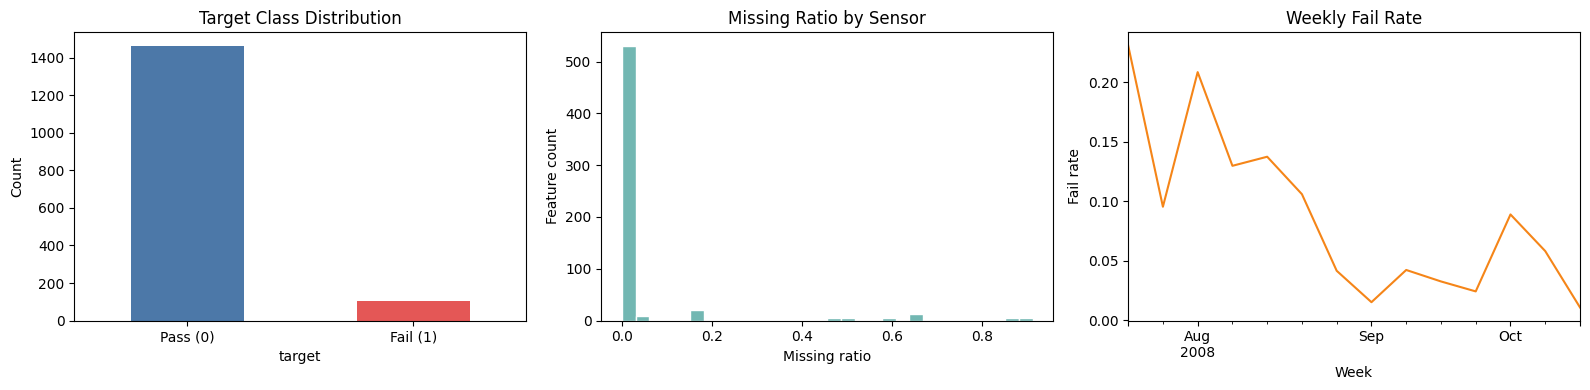

In [4]:
# Lightweight EDA plots; no model training happens here.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

class_counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set_title("Target Class Distribution")
axes[0].set_xticklabels(["Pass (0)", "Fail (1)"], rotation=0)
axes[0].set_ylabel("Count")

axes[1].hist(missing_ratio, bins=30, color="#72B7B2", edgecolor="white")
axes[1].set_title("Missing Ratio by Sensor")
axes[1].set_xlabel("Missing ratio")
axes[1].set_ylabel("Feature count")

weekly_fail_rate = (
    pd.DataFrame({"timestamp": labels_df["timestamp"], "target": y})
    .dropna()
    .set_index("timestamp")
    .resample("W")["target"]
    .mean()
)
weekly_fail_rate.plot(ax=axes[2], color="#F58518")
axes[2].set_title("Weekly Fail Rate")
axes[2].set_xlabel("Week")
axes[2].set_ylabel("Fail rate")

plt.tight_layout()
plt.show()


In [5]:
observations = [
    f"- The fail class is rare: {fail_count} of {len(y)} samples are labeled as fail.",
    f"- The feature matrix has {X_raw.shape[1]} loaded sensor columns, which is high-dimensional relative to {fail_count} fail cases.",
    f"- {int((missing_ratio > 0).sum())} sensor columns contain at least one missing value.",
    f"- {constant_features} constant features and {near_constant_features} near-constant features support the need for preprocessing.",
    "- The timestamps make time-based validation a reasonable possible extension, but this project uses a stratified split for the current workflow.",
]

display(Markdown("### EDA Observations\n" + "\n".join(observations)))


### EDA Observations
- The fail class is rare: 104 of 1567 samples are labeled as fail.
- The feature matrix has 590 loaded sensor columns, which is high-dimensional relative to 104 fail cases.
- 538 sensor columns contain at least one missing value.
- 116 constant features and 122 near-constant features support the need for preprocessing.
- The timestamps make time-based validation a reasonable possible extension, but this project uses a stratified split for the current workflow.

## 5. Why Accuracy Is Misleading

The fail class is rare. A model can have high raw accuracy while still missing the fail cases that are most important for screening.

The table below reads validation results from `outputs/metrics/validation_metrics.csv` and compares a majority baseline with two Random Forest operating points.


In [6]:
validation_metrics = pd.read_csv(METRICS_DIR / "validation_metrics.csv")
rf_improvement = pd.read_csv(METRICS_DIR / "rf_improvement_table.csv")
final_test_metrics = pd.read_csv(METRICS_DIR / "final_test_metrics.csv")
final_feature_importance = pd.read_csv(METRICS_DIR / "final_feature_importance.csv")

selected_experiment_name = str(final_test_metrics.iloc[0]["selected_experiment_name"])
selected_validation_rows = validation_metrics.loc[
    validation_metrics["experiment_name"] == selected_experiment_name
]
if selected_validation_rows.empty:
    raise ValueError(f"Selected experiment is missing from validation metrics: {selected_experiment_name}")
selected_validation = selected_validation_rows.iloc[0]

comparison_names = [
    "dummy_majority_baseline",
    "rf_current_config_threshold_050",
    selected_experiment_name,
]
accuracy_example = validation_metrics[
    validation_metrics["experiment_name"].isin(dict.fromkeys(comparison_names))
][
    [
        "experiment_name",
        "threshold",
        "accuracy",
        "recall",
        "f2",
        "balanced_accuracy",
        "tp",
        "fp",
        "fn",
        "tn",
        "review_count",
        "review_rate",
    ]
].rename(
    columns={
        "review_count": "flagged_sample_count",
        "review_rate": "flagged_sample_rate",
    }
)

display(accuracy_example)

current_050 = validation_metrics.loc[
    validation_metrics["experiment_name"] == "rf_current_config_threshold_050"
].iloc[0]
validation_fail_total = int(selected_validation["tp"] + selected_validation["fn"])
validation_total = int(selected_validation[["tp", "fp", "fn", "tn"]].sum())

summary_text = (
    f"At threshold {current_050['threshold']:.2f}, the current Random Forest configuration detected "
    f"{int(current_050['tp'])} of {validation_fail_total} validation fail cases. "
    f"With the validation-selected threshold {selected_validation['threshold']:.3f}, it detected "
    f"{int(selected_validation['tp'])} of {validation_fail_total} validation fail cases and flagged "
    f"{int(selected_validation['review_count'])} of {validation_total} validation samples."
)
display(Markdown(summary_text))


,experiment_name,threshold,accuracy,recall,f2,balanced_accuracy,tp,fp,fn,tn,flagged_sample_count,flagged_sample_rate
0,dummy_majority_baseline,0.50,0.933121,0.000000,0.000000,0.500000,0,0,21,293,0,0.000000
4,rf_current_config_threshold_050,0.50,0.933121,0.000000,0.000000,0.500000,0,0,21,293,0,0.000000
5,rf_current_config_threshold_tuned,0.11,0.710191,0.571429,0.337079,0.645783,12,82,9,211,94,0.299363


At threshold 0.50, the current Random Forest configuration detected 0 of 21 validation fail cases. With the validation-selected threshold 0.110, it detected 12 of 21 validation fail cases and flagged 94 of 314 validation samples.

## 6. Reproducible Workflow and Leakage Control

The script workflow uses a stratified train/validation/test split:

- training data fits preprocessing and model parameters
- validation data compares experiments and selects thresholds
- test data is held back for one final evaluation

Missingness filtering and imputation are fit on training data only. The notebook does not select models or tune thresholds.


## 7. Baseline and Random Forest Experiment Design

The validation experiments include:

- majority-class dummy baseline
- logistic regression with PCA baseline
- default Random Forest at threshold `0.50`
- class-balanced Random Forest at threshold `0.50`
- current Random Forest configuration at threshold `0.50`
- current Random Forest configuration with a validation-selected threshold
- small RandomizedSearchCV Random Forest comparison at threshold `0.50`
- the same randomized-search model with a validation-selected threshold

The randomized search is a small comparison step, not a broad production tuning process.


## 8. Random Forest Iterative Results

The table below is read from `outputs/metrics/rf_improvement_table.csv`. It focuses on fail-class recall, F2-score, balanced accuracy, PR-AUC, confusion counts, and flagged sample rate.


In [7]:
rf_columns = [
    "experiment_name",
    "threshold",
    "recall",
    "f2",
    "balanced_accuracy",
    "pr_auc",
    "tp",
    "fp",
    "fn",
    "tn",
    "review_count",
    "review_rate",
]
rf_table = rf_improvement[rf_columns].rename(
    columns={
        "review_count": "flagged_sample_count",
        "review_rate": "flagged_sample_rate",
    }
)
display(rf_table)

display(
    Markdown(
        f"The final validation candidate is `{selected_experiment_name}`. Its threshold came from validation data, "
        f"and it flagged {int(selected_validation['review_count'])} validation samples."
    )
)


,experiment_name,threshold,recall,f2,balanced_accuracy,pr_auc,tp,fp,fn,tn,flagged_sample_count,flagged_sample_rate
0,rf_default_threshold_050,0.50,0.000000,0.000000,0.500000,0.141650,0,0,21,293,0,0.000000
1,rf_balanced_threshold_050,0.50,0.000000,0.000000,0.500000,0.132929,0,0,21,293,0,0.000000
2,rf_current_config_threshold_050,0.50,0.000000,0.000000,0.500000,0.132929,0,0,21,293,0,0.000000
3,rf_current_config_threshold_tuned,0.11,0.571429,0.337079,0.645783,0.132929,12,82,9,211,94,0.299363
4,rf_random_search_best_threshold_050,0.50,0.000000,0.000000,0.498294,0.144647,0,1,21,292,1,0.003185
5,rf_random_search_best_threshold_tuned,0.13,0.571429,0.329670,0.638957,0.144647,12,86,9,207,98,0.312102


The final validation candidate is `rf_current_config_threshold_tuned`. Its threshold came from validation data, and it flagged 94 validation samples.

## 9. Threshold Selection and Flagged Sample Rate

The script workflow selects tuned thresholds on validation data using F2-score. F2-score weights recall more than precision.

The source CSV uses the metric name `review_rate`. In this notebook, `review_rate` is interpreted as the flagged sample rate:

`review_rate = (TP + FP) / total_samples`

A lower threshold can improve fail detection, but it also increases false positives and the flagged sample rate.


In [8]:
selected_validation_table = selected_validation_rows[
    [
        "experiment_name",
        "threshold_source",
        "threshold",
        "recall",
        "f2",
        "balanced_accuracy",
        "precision",
        "tp",
        "fp",
        "fn",
        "tn",
        "review_count",
        "review_rate",
    ]
].rename(
    columns={
        "review_count": "flagged_sample_count",
        "review_rate": "flagged_sample_rate",
    }
)

display(selected_validation_table)


,experiment_name,threshold_source,threshold,recall,f2,balanced_accuracy,precision,tp,fp,fn,tn,flagged_sample_count,flagged_sample_rate
5,rf_current_config_threshold_tuned,validation_f2,0.11,0.571429,0.337079,0.645783,0.12766,12,82,9,211,94,0.299363


## 10. MLflow Experiment Tracking Summary

The script workflow uses local MLflow tracking:

- tracking URI: `sqlite:///mlflow.db`
- experiment name: `secom-pass-fail-screening`
- runs log model settings, validation metrics, selected thresholds, confusion counts, and artifacts
- local MLflow files are ignored by Git

The notebook does not require the MLflow UI to be running.


## 11. Final Holdout Test Evaluation

The selected validation candidate was evaluated once on the untouched holdout test set. The table and summary below are read from `outputs/metrics/final_test_metrics.csv`.


In [9]:
final_columns = [
    "selected_experiment_name",
    "threshold",
    "recall",
    "f2",
    "balanced_accuracy",
    "pr_auc",
    "roc_auc",
    "tp",
    "fp",
    "fn",
    "tn",
    "review_count",
    "review_rate",
]
final_table = final_test_metrics[final_columns].rename(
    columns={
        "review_count": "flagged_sample_count",
        "review_rate": "flagged_sample_rate",
    }
)
display(final_table)

final_row = final_test_metrics.iloc[0]
test_fail_total = int(final_row["tp"] + final_row["fn"])
test_total = int(final_row[["tp", "fp", "fn", "tn"]].sum())
final_summary = (
    f"The final model `{final_row['selected_experiment_name']}` used threshold {final_row['threshold']:.3f}. "
    f"On the holdout test split, it detected {int(final_row['tp'])} of {test_fail_total} fail cases and "
    f"flagged {int(final_row['review_count'])} of {test_total} samples. "
    f"The flagged sample rate was {final_row['review_rate']:.4f}."
)
display(Markdown(final_summary))


,selected_experiment_name,threshold,recall,f2,balanced_accuracy,pr_auc,roc_auc,tp,fp,fn,tn,flagged_sample_count,flagged_sample_rate
0,rf_current_config_threshold_tuned,0.11,0.52381,0.364238,0.666342,0.219166,0.797822,11,56,10,237,67,0.213376


The final model `rf_current_config_threshold_tuned` used threshold 0.110. On the holdout test split, it detected 11 of 21 fail cases and flagged 67 of 314 samples. The flagged sample rate was 0.2134.

### Final Confusion Matrix

The confusion matrix below is generated directly from `final_test_metrics.csv`.


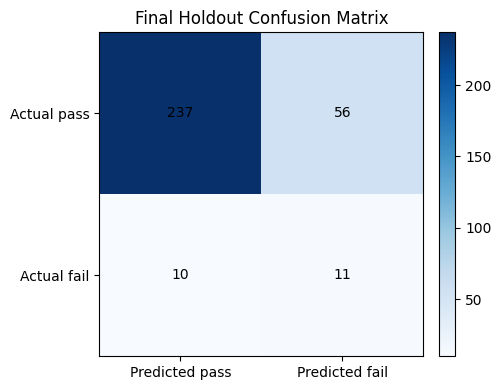

In [10]:
tn = int(final_row["tn"])
fp = int(final_row["fp"])
fn = int(final_row["fn"])
tp = int(final_row["tp"])
confusion_matrix = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion_matrix, cmap="Blues")
ax.set_xticks([0, 1], labels=["Predicted pass", "Predicted fail"])
ax.set_yticks([0, 1], labels=["Actual pass", "Actual fail"])
ax.set_title("Final Holdout Confusion Matrix")

for row in range(confusion_matrix.shape[0]):
    for col in range(confusion_matrix.shape[1]):
        ax.text(col, row, confusion_matrix[row, col], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Final ROC and PR Curves

These curve figures were generated by `scripts/evaluate_final_model.py` during final evaluation.

![Final ROC curve](../outputs/figures/final_roc_curve.png)

![Final PR curve](../outputs/figures/final_pr_curve.png)


## 12. Feature Importance and Interpretation

Feature importance is treated as model-driven signal ranking, not process-causal explanation. The SECOM sensors are anonymous, so these rankings should not be interpreted as physical root causes.


,rank,feature,importance
0,1,sensor_060,0.017984
1,2,sensor_104,0.015005
2,3,sensor_181,0.008863
3,4,sensor_478,0.007840
4,5,sensor_034,0.007401
5,6,sensor_206,0.007347
6,7,sensor_342,0.007073
7,8,sensor_126,0.007007
8,9,sensor_130,0.006728
9,10,sensor_065,0.006266


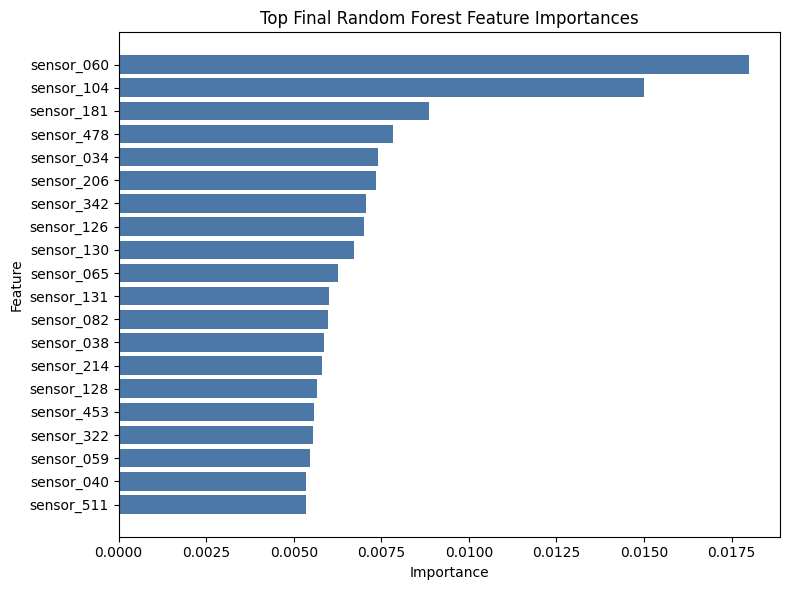

In [11]:
top_features = final_feature_importance.head(20).copy()
display(top_features)

fig, ax = plt.subplots(figsize=(8, 6))
plot_data = top_features.iloc[::-1]
ax.barh(plot_data["feature"], plot_data["importance"], color="#4C78A8")
ax.set_title("Top Final Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## 13. Prototype Benchmark, Cost, and Explainability Artifacts

The final portfolio app also uses prototype benchmark, threshold / cost, and explainability artifacts. The cells below read those reviewed artifacts without retraining models.


In [12]:
benchmark = pd.read_csv(METRICS_DIR / "benchmark_model_comparison_prototype.csv")
cost_selected = pd.read_csv(METRICS_DIR / "cost_selected_thresholds_prototype.csv")
top_signals = pd.read_csv(METRICS_DIR / "top_sensor_signals_prototype.csv")

benchmark_columns = [
    "model_name",
    "model_group",
    "status",
    "threshold",
    "recall",
    "precision",
    "f2",
    "pr_auc",
    "roc_auc",
    "flagged_sample_rate",
]
display(Markdown("### Prototype benchmark snapshot"))
display(benchmark[benchmark_columns].sort_values("f2", ascending=False))

display(Markdown("### Selected cost thresholds snapshot"))
display(
    cost_selected[
        [
            "model_name",
            "scenario",
            "selected_threshold",
            "total_cost",
            "recall",
            "precision",
            "f2",
            "flagged_sample_rate",
        ]
    ].head(12)
)

display(Markdown("### Top model-important sensor signals"))
display(top_signals.head(12))


### Prototype benchmark snapshot

,model_name,model_group,status,threshold,recall,precision,f2,pr_auc,roc_auc,flagged_sample_rate
2,random_forest_reference,baseline_reference,completed,0.115,0.571429,0.127660,0.337079,0.114271,0.625061,0.299363
3,xgboost_cost_sensitive,literature_sota_inspired_prototype,completed,0.115,0.619048,0.116071,0.331633,0.115134,0.617585,0.356688
5,xgboost_training_only_smote,literature_sota_inspired_prototype,completed,0.050,0.619048,0.104839,0.312500,0.125290,0.640176,0.394904
1,logistic_regression_pca_baseline,baseline_reference,completed,0.305,0.380952,0.163265,0.300752,0.150871,0.643263,0.156051
4,lightgbm_class_weighted,literature_sota_inspired_prototype,completed,0.085,0.190476,0.117647,0.169492,0.107167,0.605558,0.108280
0,dummy_majority_baseline,baseline_reference,completed,0.050,0.000000,0.000000,0.000000,0.066879,0.500000,0.000000


### Selected cost thresholds snapshot

,model_name,scenario,selected_threshold,total_cost,recall,precision,f2,flagged_sample_rate
0,dummy_majority_baseline,balanced_review,0.05,105.0,0.000000,0.000000,0.000000,0.000000
1,dummy_majority_baseline,balanced_review__high_review,0.05,105.0,0.000000,0.000000,0.000000,0.000000
2,dummy_majority_baseline,balanced_review__moderate_review,0.05,105.0,0.000000,0.000000,0.000000,0.000000
3,dummy_majority_baseline,quality_first,0.05,210.0,0.000000,0.000000,0.000000,0.000000
4,dummy_majority_baseline,quality_first__high_review,0.05,210.0,0.000000,0.000000,0.000000,0.000000
5,dummy_majority_baseline,quality_first__moderate_review,0.05,210.0,0.000000,0.000000,0.000000,0.000000
6,dummy_majority_baseline,strict_quality,0.05,420.0,0.000000,0.000000,0.000000,0.000000
7,dummy_majority_baseline,strict_quality__high_review,0.05,420.0,0.000000,0.000000,0.000000,0.000000
8,dummy_majority_baseline,strict_quality__moderate_review,0.05,420.0,0.000000,0.000000,0.000000,0.000000
9,lightgbm_class_weighted,balanced_review,0.15,101.0,0.142857,0.214286,0.153061,0.044586


### Top model-important sensor signals

,feature,models_where_top,model_count,best_rank,mean_rank,notes
0,sensor_091,random_forest_reference;xgboost_cost_sensitive,2,2,2.500000,Anonymous sensor feature appearing in top prot...
1,sensor_022,random_forest_reference;xgboost_cost_sensitive,2,2,3.500000,Anonymous sensor feature appearing in top prot...
2,sensor_334,random_forest_reference;xgboost_cost_sensitive,2,3,4.500000,Anonymous sensor feature appearing in top prot...
3,sensor_060,random_forest_reference;xgboost_cost_sensitive,2,1,5.666667,Anonymous sensor feature appearing in top prot...
4,sensor_104,random_forest_reference;xgboost_cost_sensitive,2,1,6.000000,Anonymous sensor feature appearing in top prot...
5,sensor_011,random_forest_reference;xgboost_cost_sensitive,2,7,7.000000,Anonymous sensor feature appearing in top prot...
6,sensor_337,random_forest_reference;xgboost_cost_sensitive,2,6,7.000000,Anonymous sensor feature appearing in top prot...
7,sensor_065,random_forest_reference;xgboost_cost_sensitive,2,4,7.500000,Anonymous sensor feature appearing in top prot...
8,sensor_574,random_forest_reference;xgboost_cost_sensitive,2,6,7.500000,Anonymous sensor feature appearing in top prot...
9,sensor_034,random_forest_reference;xgboost_cost_sensitive,2,1,8.250000,Anonymous sensor feature appearing in top prot...


## 14. Responsible Limitations

Main limitations:

- the fail class is small
- one stratified split is used for the current prototype artifacts
- validation and test splits each contain a small number of fail cases
- no real manufacturing cost function is available for false positives and false negatives
- cost scenarios are illustrative and not validated manufacturing costs
- sensor names are anonymous
- feature importance does not explain physical cause
- the project is a portfolio app for screening decision support, not a production system


## 15. Final Takeaways

The main takeaway is that threshold choice matters for fail-class screening.

Raw accuracy is not the right story for this dataset. The more useful view is recall, F2-score, balanced accuracy, PR-AUC, confusion counts, and flagged sample rate.

The Streamlit app, local API, controlled summaries, generated CSV outputs, reports, and this notebook make the project easier to review. The notebook is a supporting artifact; the primary public interface is the Streamlit app.


## 16. How to Reproduce the Script Workflow

Run these commands from the repository root when you want to recreate artifacts locally:

```bash
python -m pytest
python -m ruff check .
python scripts/run_rf_experiments.py --config configs/rf_experiments.yaml
python scripts/evaluate_final_model.py --config configs/final_rf.yaml
python scripts/run_model_benchmark_prototype.py --config configs/model_benchmark_prototype.yaml
python scripts/run_cost_threshold_analysis_prototype.py --config configs/cost_scenarios_prototype.yaml
python scripts/run_explainability_prototype.py --config configs/explainability_prototype.yaml
python scripts/export_experiment_summary.py
```

Local MLflow tracking can be inspected with:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Local MLflow files are ignored by Git. Do not commit `mlflow.db`, `mlruns/`, `mlartifacts/`, `.env`, or `.streamlit/secrets.toml`.
